## Прогнозирование годовых медицинских расходов пациента на основе табличных данных

## Участники:

- Алёна Лозинская
- Валентина Кулакова
- Дмитрий Волобуев
- Артур Григорян
- Ильсия Коткова
- Матвей Радаев

## Характеристика датасета

Общее количество записей: 5000  
Всего признаков: 20  
Тип данных: Синтетические  
Отсутствующие значения: Нет  

Описание признаков:
1. Демографические признаки:

| Столбец | Описание |
|----------|----------------------|
| **age** | Возраст пациента (18–90 лет) |
| **gender** | Пол пациента (мужской/женский) | 
| **bmi** | Индекс массы тела | 
  

2. Образ жизни и поведение в отношении здоровья

| Столбец | Описание |
|----------|----------------------|
| **smoker** | Статус курения (Да / Нет) |
| **physical_activity_level** | Уровень физической активности (низкий / средний / высокий) | 
| **daily_steps** | Среднее количество шагов в день | 
| **sleep_hours** | Средняя продолжительность сна (в часах) |
| **stress_level** | Уровень стресса по шкале от 1 до 10 | 

3. Медицинские состояния

| Столбец | Описание |
|----------|----------------------|
| **diabetes** | Наличие диабета (0 = Нет, 1 = Да) |
| **hypertension** | Индикатор высокого кровяного давления | 
| **heart_disease** | История сердечных заболеваний | 
| **asthma** | Индикатор состояния астмы |

4. Использование медицинских услуг

| Столбец | Описание |
|----------|----------------------|
| **doctor_visits_per_year** | Количество визитов к врачу в год |
| **hospital_admissions** | Количество госпитализаций | 
| **medication_count** | Количество принимаемых лекарств | 

5. Страхование и местоположение

| Столбец | Описание |
|----------|----------------------|
| **insurance_type** | Вид страхования (Отсутствует / Государственное / Частное) |
| **insurance_coverage_pct** | Процент страхового покрытия | 
| **city_type** | Жилой район (городской / полугородской / сельский) | 

6. Историческая стоимость

| Столбец | Описание |
|----------|----------------------|
| **previous_year_cost** | Медицинские расходы за предыдущий год |

7. Целевая переменная

| Столбец | Описание |
|----------|----------------------|
| **annual_medical_cost** | Общие годовые расходы на медицинское обслуживание (долл. США) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik import resources, report
from time import perf_counter

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, FunctionTransformer, PolynomialFeatures, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
import shap

c:\Users\sulta\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Установим random state для воспроизводимости результатов.

In [2]:
RANDOM_STATE = 42

# Exploratory Data Analysis (EDA) 

In [3]:
df = pd.read_csv('C:/Users/sulta/Downloads/archive/medical_cost_prediction_dataset.csv')

df.head()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,Private,80,Semi-Urban,10885,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,Government,64,Semi-Urban,18722,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,NaN,0,Urban,4196,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,Government,70,Urban,11128,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,Private,77,Urban,15110,3202.52


In [4]:
# выделяем целевую переменную 
target = df['annual_medical_cost']

In [5]:
# определяем типы признаков
df.dtypes

age                          int64
gender                      object
bmi                        float64
smoker                      object
diabetes                     int64
hypertension                 int64
heart_disease                int64
asthma                       int64
physical_activity_level     object
daily_steps                  int64
sleep_hours                float64
stress_level                 int64
doctor_visits_per_year       int64
hospital_admissions          int64
medication_count             int64
insurance_type              object
insurance_coverage_pct       int64
city_type                   object
previous_year_cost           int64
annual_medical_cost        float64
dtype: object

Для признаков diabetes, hypertension, heart_disease и asthma указан тип int64, хотя по смыслу это категориальные признаки, т.к. их значения могут быть только 2: 0 = Нет, 1 = Да. Чтобы не учитывать их как другие числовые показатели с типом int64, для удобства EDA присвоим им тип object и сделаем значения по аналогии с признаком smoker (0 = No, 1 = Yes).

In [6]:
# заменяем числовые значения на строковые метки
df['diabetes'] = df['diabetes'].replace({1: 'Yes', 0: 'No'})
df['hypertension'] = df['hypertension'].replace({1: 'Yes', 0: 'No'})
df['heart_disease'] = df['heart_disease'].replace({1: 'Yes', 0: 'No'})
df['asthma'] = df['asthma'].replace({1: 'Yes', 0: 'No'})

In [7]:
# проверяем сколько нулевых значений

print("Количество нулевых значений в признаках:")
display(df.eq(0).sum())

Количество нулевых значений в признаках:


age                           0
gender                        0
bmi                           0
smoker                        0
diabetes                      0
hypertension                  0
heart_disease                 0
asthma                        0
physical_activity_level       0
daily_steps                   0
sleep_hours                   0
stress_level                  0
doctor_visits_per_year       81
hospital_admissions        1819
medication_count            609
insurance_type                0
insurance_coverage_pct     1048
city_type                     0
previous_year_cost            0
annual_medical_cost           0
dtype: int64

Нулевые значения присутствуют только в тех признаках, в которых они могут быть по смыслу.

In [8]:
# проверка на дубликаты
df.duplicated().sum()

np.int64(0)

Данные не содержат повторов. Дополнительная очистка от дубликатов не требуется.

In [9]:
# основные описательные статистики
df.describe()

,age,bmi,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost,annual_medical_cost
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,53.299000,25.970820,7993.216800,6.488140,5.475400,4.030600,1.001000,3.509000,57.953000,10248.515400,8048.886894
std,20.646851,5.046651,4052.127069,1.443361,2.892312,2.010689,0.978566,2.292721,31.627742,5626.095015,7071.020228
min,18.000000,6.400000,1004.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,500.000000,404.950000
25%,36.000000,22.600000,4545.000000,5.200000,3.000000,3.000000,0.000000,1.000000,53.000000,5342.750000,3241.977500
50%,53.000000,25.900000,7989.000000,6.500000,5.000000,4.000000,1.000000,3.000000,71.000000,10281.000000,5539.780000
75%,71.000000,29.400000,11532.250000,7.700000,8.000000,5.000000,2.000000,6.000000,79.000000,15034.500000,10094.097500
max,89.000000,43.600000,14999.000000,9.000000,10.000000,14.000000,6.000000,7.000000,94.000000,19996.000000,44792.100000


 - Подозрительный минимум у признака bmi (индекс массы тела) - 6.4. Это аномально низко, т.к. обычный диапазон 16-40. Это может быть ошибкой ввода или экстремальным случаем;
 - Правостороннее распределение по целевой переменной. Есть небольшая группа людей с экстремально высокими расходами (в 5-8 раз выше среднего);
 - Большой разброс значений (age: 18-89, annual_medical_cost: 404 - 44792). Для моделей, чувствительных к масштабу (SVM, KNN, Neural Networks, Linear Regression), потребуется нормализация (MinMaxScaler) или стандартизация (StandardScaler).

In [10]:
# находим числовые признаки
numeric = [col for col in df.select_dtypes(include=['number']).columns if col != 'annual_medical_cost']
print(f"Найдено числовых признаков: {len(numeric)} -> {numeric}\n")

Найдено числовых признаков: 10 -> ['age', 'bmi', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'insurance_coverage_pct', 'previous_year_cost']



In [11]:
# находим категориальные признаки
categorical = df.select_dtypes(include=['object']).columns.tolist()
print(f"Найдено категориальных признаков: {len(categorical)} -> {categorical}\n")

Найдено категориальных признаков: 9 -> ['gender', 'smoker', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'physical_activity_level', 'insurance_type', 'city_type']



## 1. Визуализации числовых и категориальных переменных

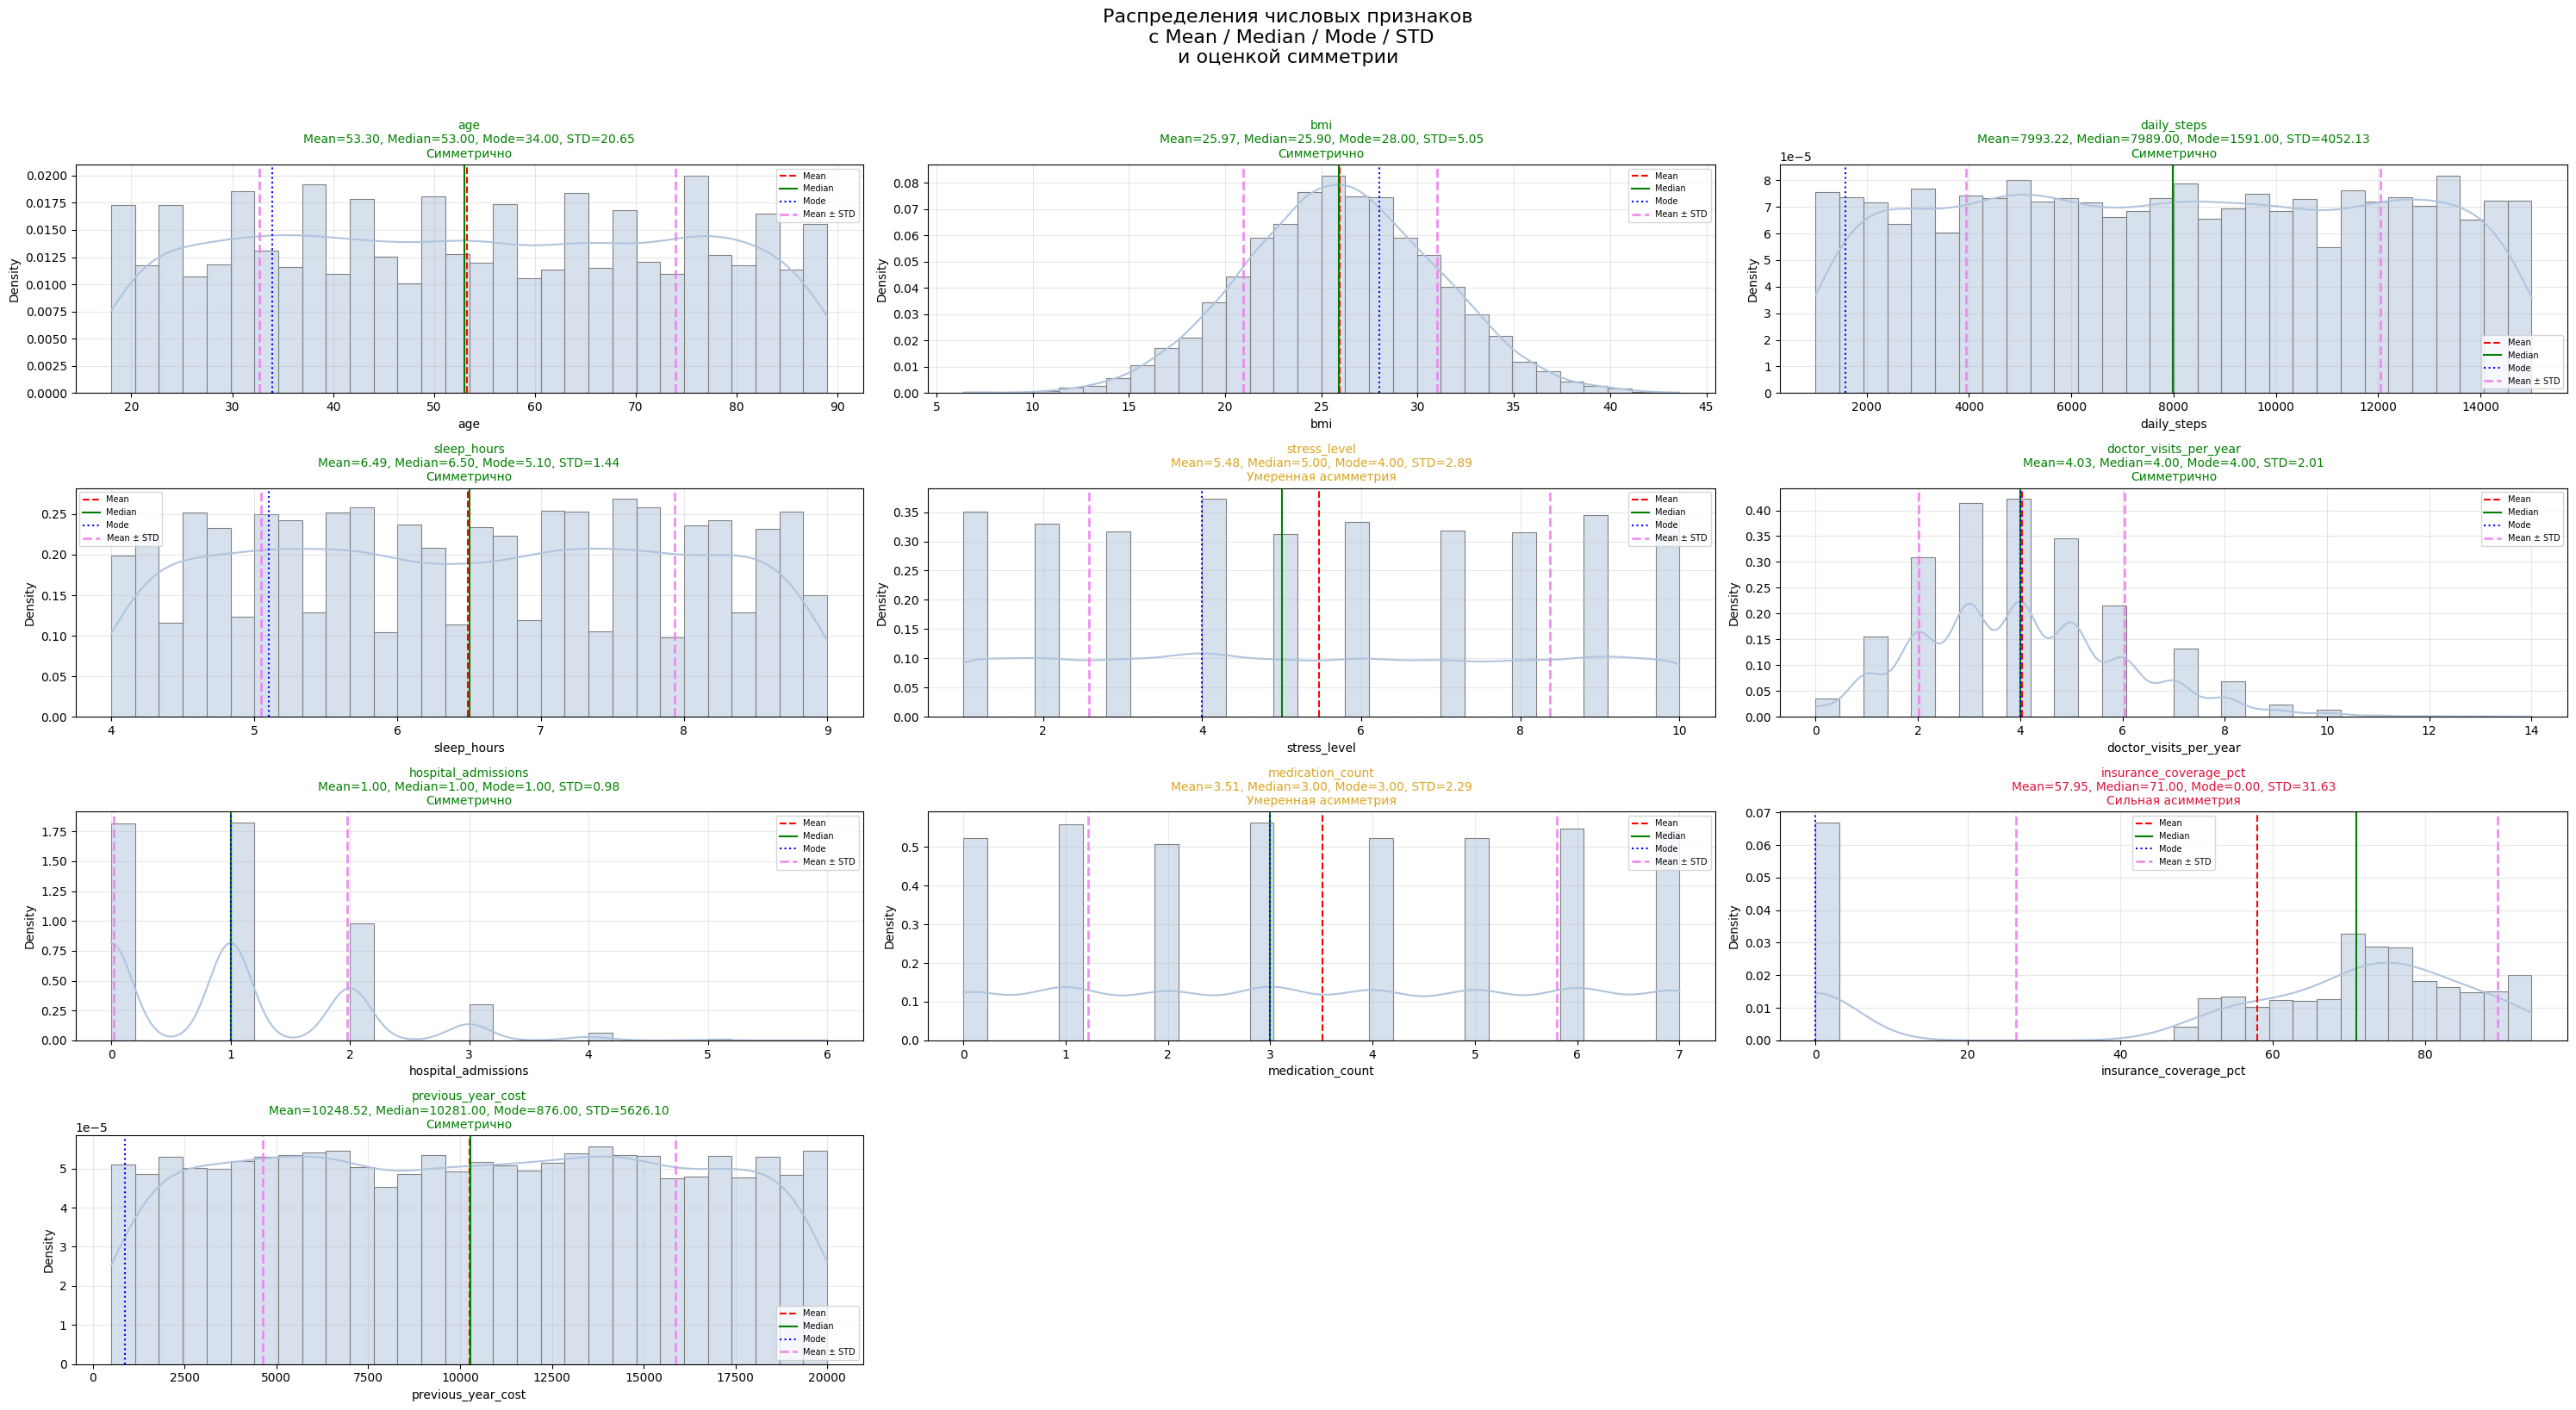

In [12]:
# распределения числовых признаков
n_cols = 3
n_rows = (len(numeric) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric):

    data = df[col].dropna()
   
    mean_val = data.mean()
    median_val = data.median()
    mode_val = data.mode()[0] if not data.mode().empty else np.nan
    std_val = data.std()

    diff = abs(mean_val - median_val)
    skew_ratio = diff / std_val if std_val != 0 else 0

    if skew_ratio < 0.1:
        color = 'green'
        label = 'Симметрично'
    elif skew_ratio < 0.3:
        color = 'goldenrod'
        label = 'Умеренная асимметрия'
    else:
        color = 'crimson'
        label = 'Сильная асимметрия'

    sns.histplot(
        data, bins=30, kde=True,
        color='lightsteelblue', edgecolor='gray', linewidth=0.8,
        ax=axes[i], stat='density'
    )

    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label='Median')
    axes[i].axvline(mode_val, color='blue', linestyle=':', linewidth=1.5, label='Mode')
    axes[i].axvline(mean_val + std_val, color='violet', linestyle='--', linewidth=2, alpha=0.9, label='Mean ± STD')
    axes[i].axvline(mean_val - std_val, color='violet', linestyle='--', linewidth=2, alpha=0.9)

    axes[i].set_title(
        f"{col}\nMean={mean_val:.2f}, Median={median_val:.2f}, Mode={mode_val:.2f}, STD={std_val:.2f}\n{label}",
        fontsize=10, color=color
    )

    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=7)

for j in range(len(numeric), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Распределения числовых признаков\n с Mean / Median / Mode / STD\nи оценкой симметрии", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

- Большая часть признаков распределены симметрично, тогда как bmi и medication_count имеют умеренную асимметрию, а insurance_coverage_pct имеет сильную асимметрию.

- У признака previous_year_cost очень высокий разброс (STD = 5626.10), есть люди с экстремально высокими расходами (выбросы).

- Большинство людей были госпитализированы 1 раз (признак hospital_admissions, Mean = Median = Mode = 1.00), мало вариативности. Признак может иметь низкую информативность для модели.

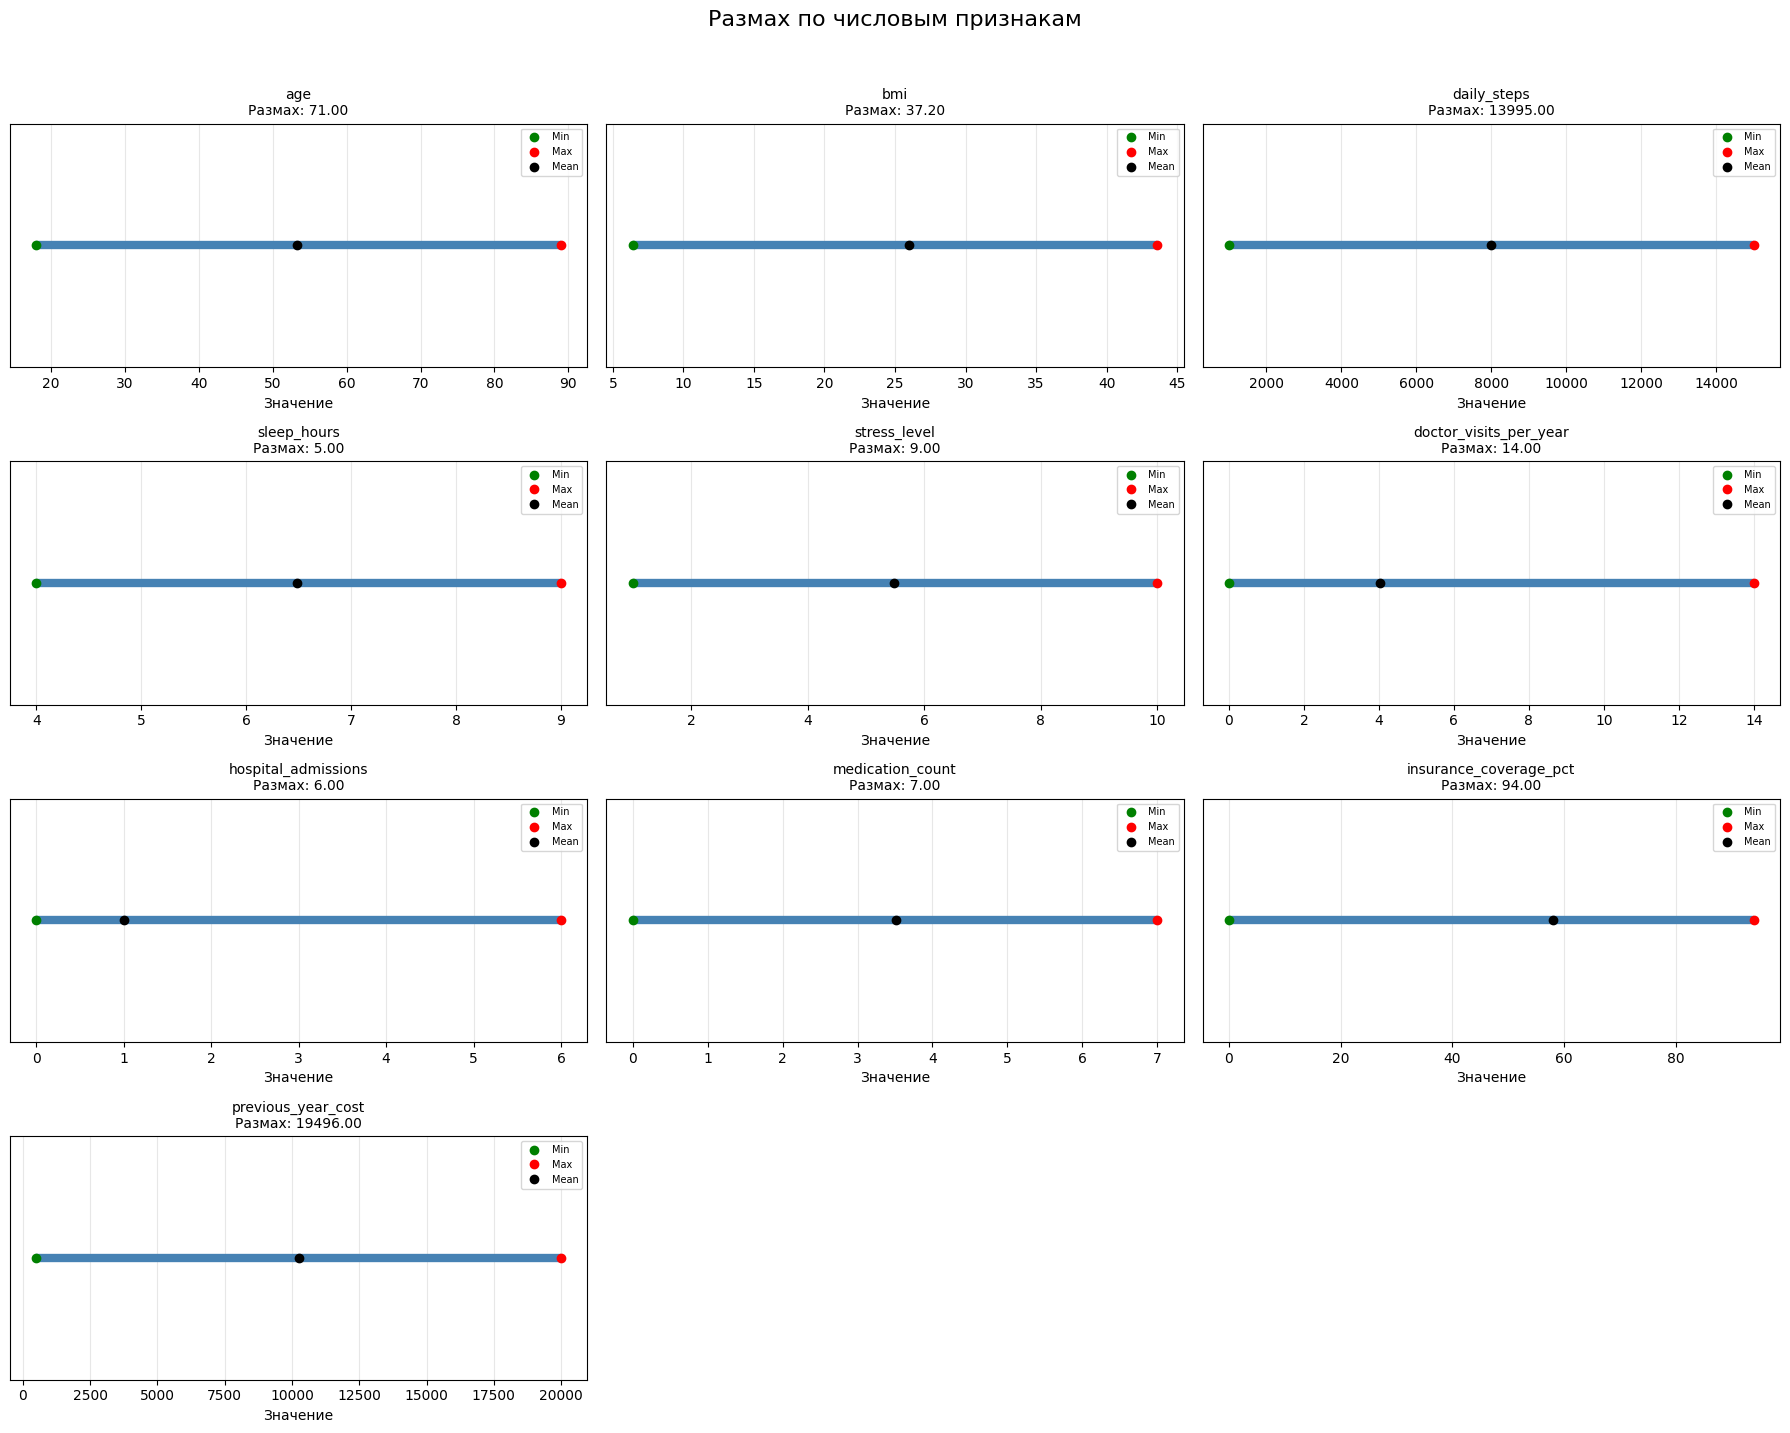

In [13]:
# размахи числовых признаков
n_cols = 3
n_rows = (len(numeric) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 3.5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric):

    data = df[col].dropna()

    min_val = data.min()
    max_val = data.max()
    mean_val = data.mean()
    rng = max_val - min_val

    axes[i].hlines(1, min_val, max_val, color='steelblue', linewidth=6)
    axes[i].plot(min_val, 1, 'go', label='Min')
    axes[i].plot(max_val, 1, 'ro', label='Max')
    axes[i].plot(mean_val, 1, 'ko', label='Mean')

    axes[i].set_title(f'{col}\nРазмах: {rng:.2f}', fontsize=10)
    axes[i].set_yticks([])
    axes[i].set_xlabel('Значение')
    axes[i].grid(axis='x', alpha=0.3)
    axes[i].legend(fontsize=7, loc='upper right')

for j in range(len(numeric), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Размах по числовым признакам", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

- График подтверждает левостороннюю асимметрию insurance_coverage_pct (среднее (~58) смещено влево, хотя максимум 94) и правосторонний хвост у признака previous_year_cost (среднее (~10,000) ближе к минимуму.)

- Интересно, что максимум признака insurance_coverage_pct 94%, а не 100%. Возможна ошибка в данных или специфика страховки.

In [14]:
# Асимметрия распределений
df[numeric].skew()

age                       0.009598
bmi                      -0.007610
daily_steps               0.004649
sleep_hours              -0.001371
stress_level              0.016389
doctor_visits_per_year    0.550993
hospital_admissions       0.888548
medication_count          0.001158
insurance_coverage_pct   -1.048162
previous_year_cost        0.003471
dtype: float64

-  У признака hospital_admissions наблюдается сильная правосторонняя асимметрия (0.89), а doctor_visits_per_year она умеренная (0.55).

- Признак previous_year_cost имеет skew = 0.003 - т.е. почти идеальную симметрию, хотя на гистограмме выглядело иначе. Возможные причины: большие выбросы с обеих сторон компенсируют друг друга или распределение может быть мультимодальным.

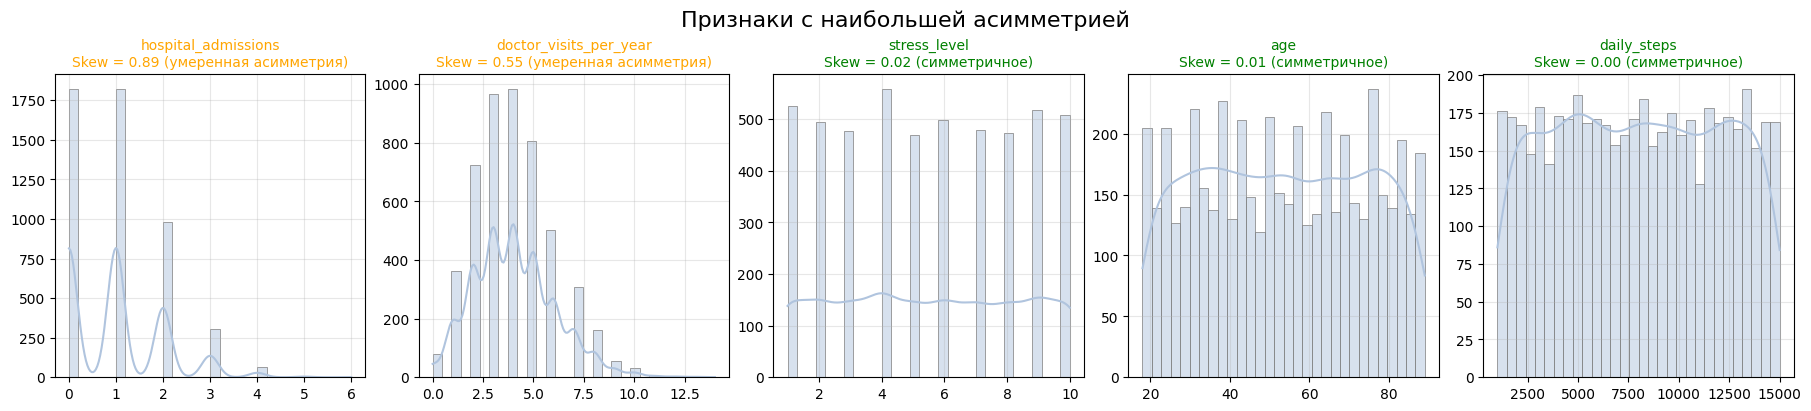

In [15]:
# признаки с наибольшей асимметрией
skew_vals = df[numeric].skew().sort_values(ascending=False)
problematic = skew_vals.head().index.tolist()

fig, axes = plt.subplots(1, len(problematic), figsize=(18, 4), constrained_layout=True)
axes = np.atleast_1d(axes) 

for ax, col in zip(axes, problematic):

    data = df[col].dropna()
    skew_val = data.skew()

    sns.histplot(data, bins=30, kde=True, ax=ax, color="lightsteelblue", edgecolor="gray")

    if abs(skew_val) < 0.3:
        color = "green"
        skew_type = "симметричное"
    elif abs(skew_val) < 1:
        color = "orange"
        skew_type = "умеренная асимметрия"
    else:
        color = "red"
        skew_type = "сильная асимметрия"

    ax.set_title(f"{col}\nSkew = {skew_val:.2f} ({skew_type})", fontsize=10, color=color)
    ax.grid(alpha=0.3)
    ax.set(xlabel="", ylabel="")

fig.suptitle("Признаки с наибольшей асимметрией", fontsize=16)
plt.show()

Большинство признаков имеют почти идеальную симметрию. К признаку insurance_coverage_pct нужно обязательно применить трансформацию, чтобы убрать левосторонний хвост.

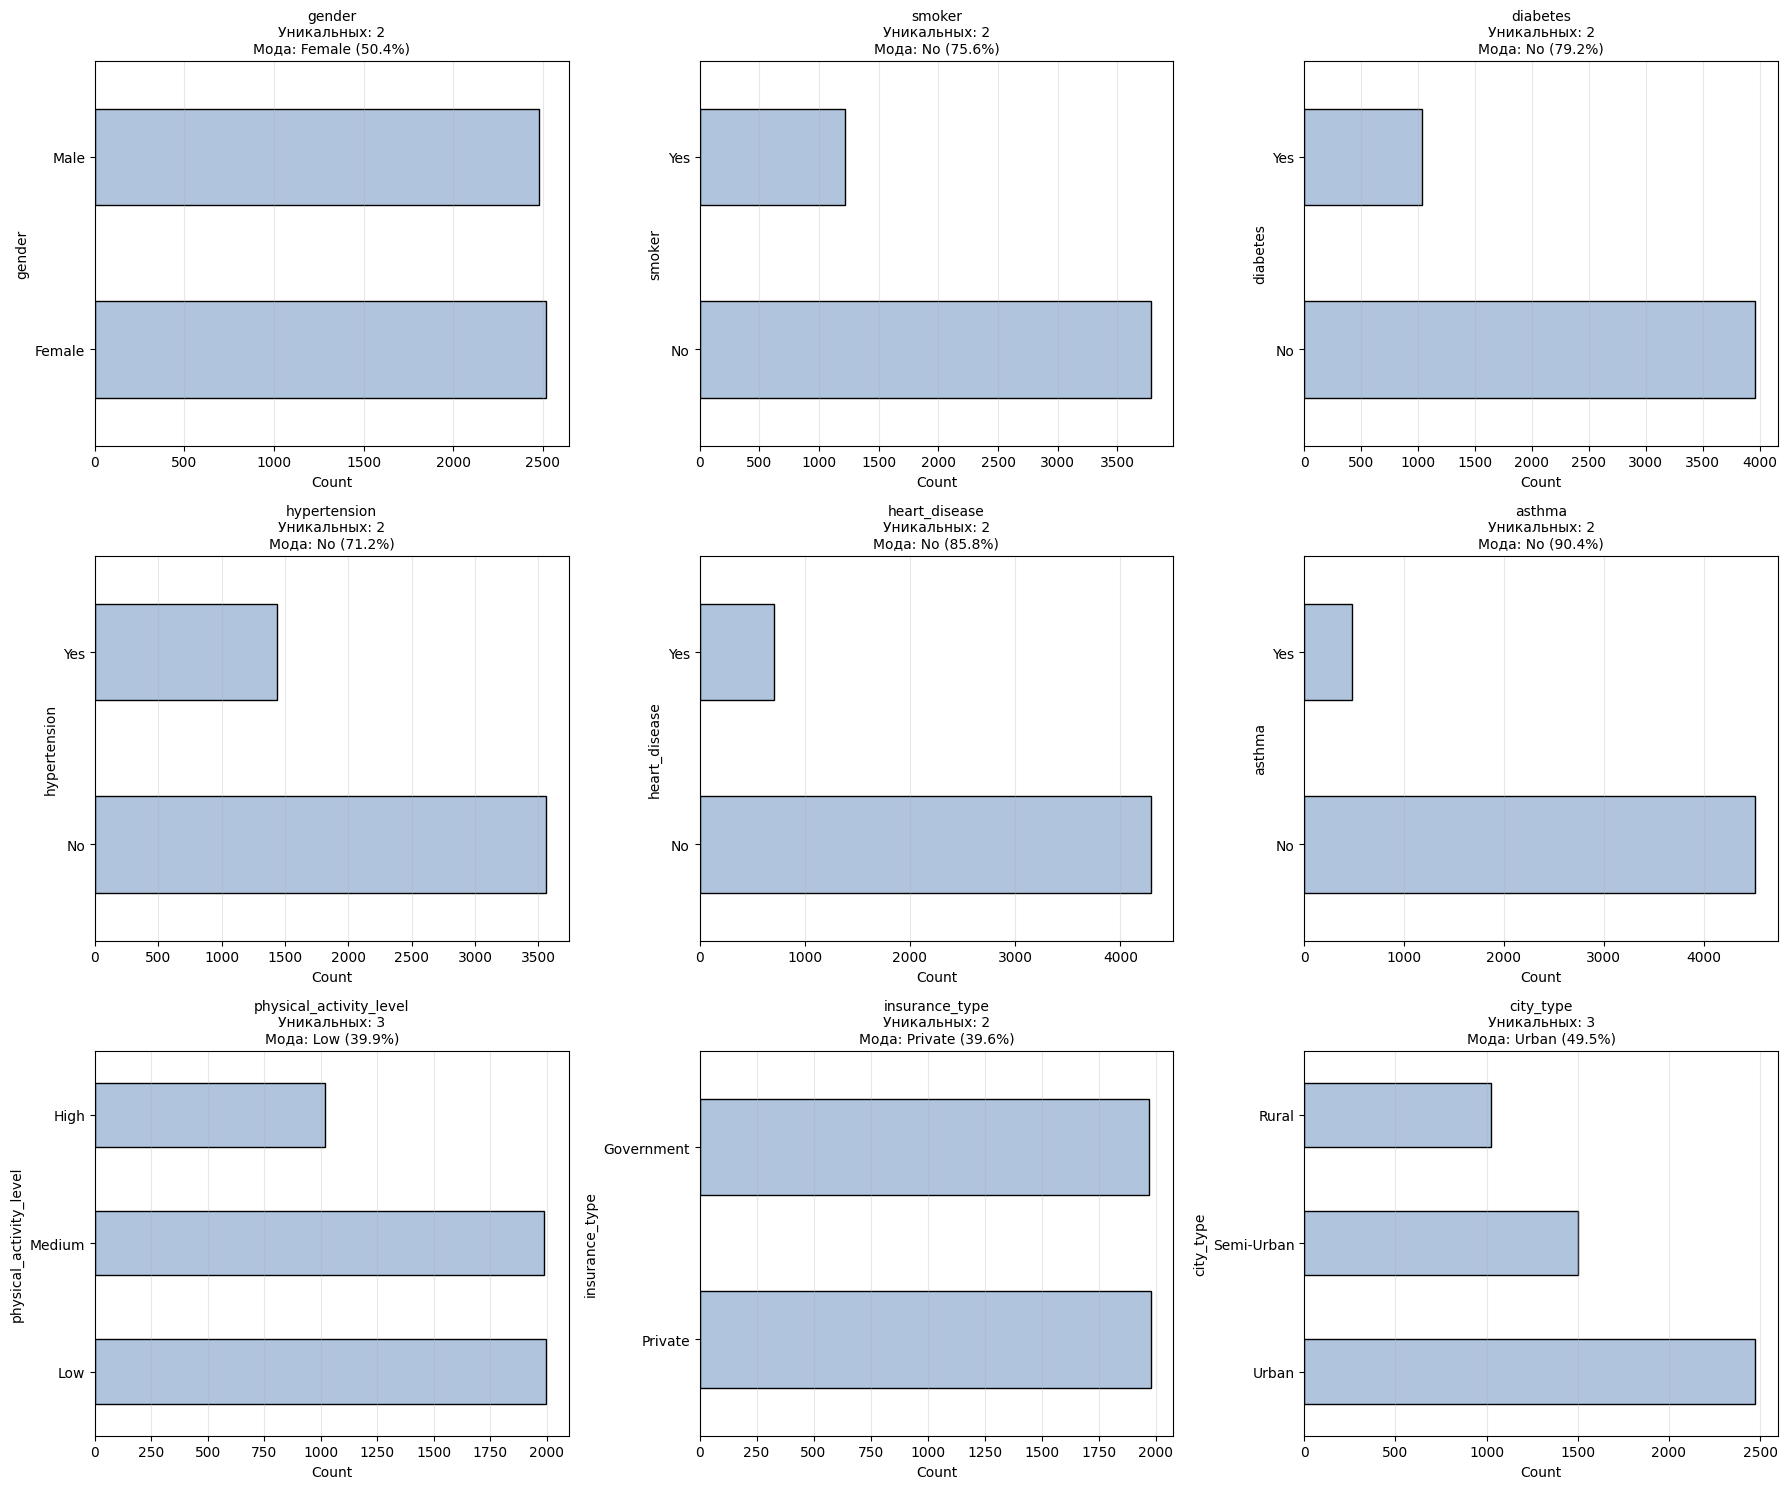

In [16]:
# распределения категориальных признаков
n_cols = 3  
n_rows = (len(categorical) + n_cols - 1) // n_cols  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical):

    counts = df[col].value_counts()
    counts.plot(kind='barh', color='lightsteelblue', edgecolor='black', ax=axes[i])
    
    mode_val = df[col].mode()[0]
    mode_percent = (counts.iloc[0] / len(df)) * 100
    
    axes[i].set_title(f'{col}\nУникальных: {df[col].nunique()}\nМода: {mode_val} ({mode_percent:.1f}%)', fontsize=10)
    axes[i].set_xlabel('Count')
    axes[i].grid(axis='x', alpha=0.3)

for j in range(len(categorical), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

Во всех "медицинских" признаках (asthma, heart_disease, diabetes, smoker, hypertension) наблюдается сильный дисбаланс классов. Категория "No" (нет заболевания/вредной привычки) значительно преобладает. Это типично для медицинских данных, где здоровых людей больше, чем больных.

interval columns not set, guessing: ['age', 'bmi', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'insurance_coverage_pct', 'previous_year_cost', 'annual_medical_cost']


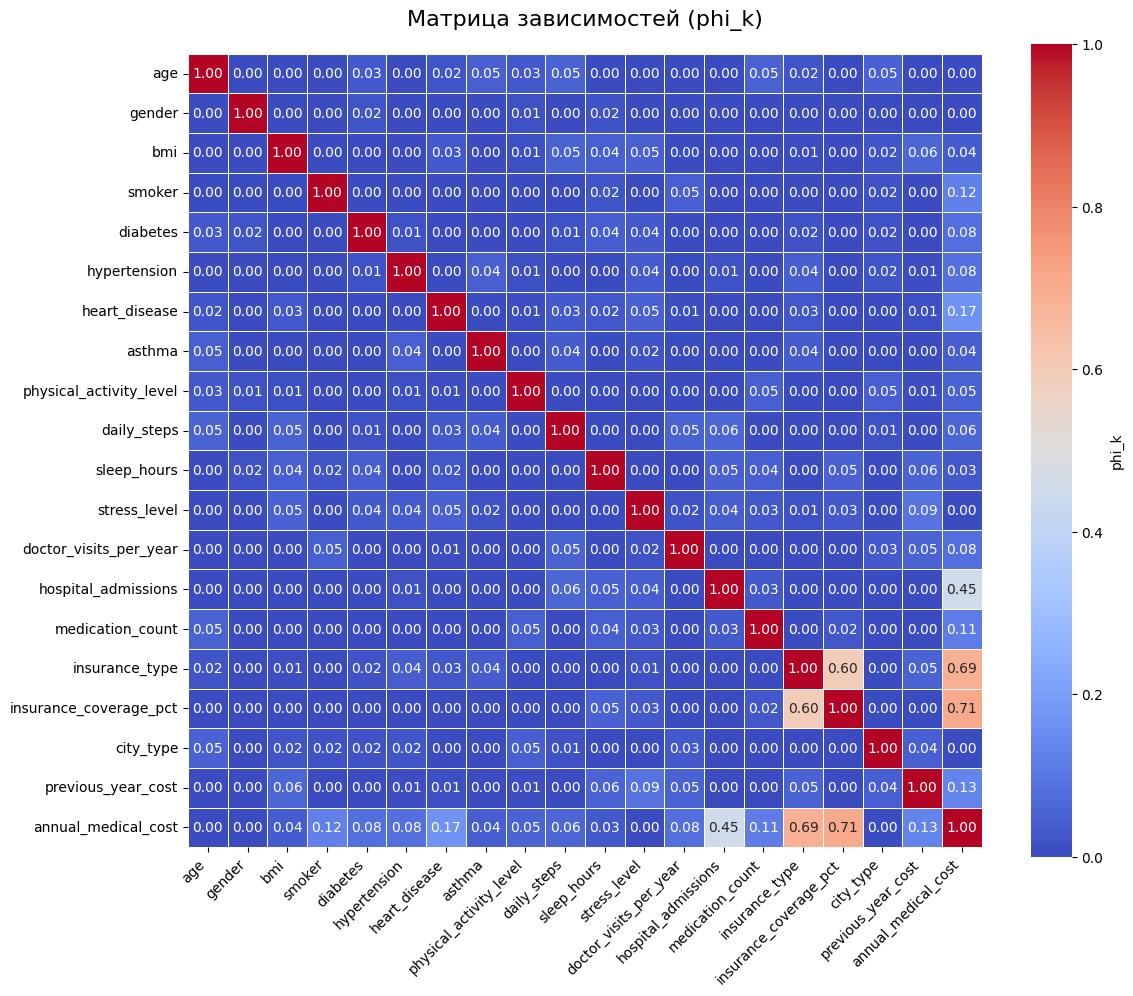

In [17]:
# матрица зависимостей всех признаков и таргета
phik_matrix = df.phik_matrix()

plt.figure(figsize=(12, 10))
sns.heatmap(
    phik_matrix,
    annot=True,         
    fmt=".2f",         
    cmap="coolwarm",    
    vmin=0,
    vmax=1,          
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "phi_k"}
)

plt.title("Матрица зависимостей (phi_k)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- Сильных связей мало: большинство зависимостей находятся на низком уровне, что говорит о том, что признаки слабо коррелируют друг с другом.
- Наиболее связанные с целевой переменной annual_medical_cost: insurance_coverage_pct (~0.71), insurance_type (~0.69), hospital_admissions (~0.45).

- Признак heart_disease (~0.17) и smoker (~0.12) имеют одни из самых заметных связей с annual_medical_cost среди всех диагнозов. Признак hospital_admissions также связан с medication_count (количество лекарств) (~0.11) и doctor_visits_per_year (~0.11). Это образует логичную цепочку: попал в больницу -> больше визитов -> больше лекарств.

## 2. Анализ целевой переменной

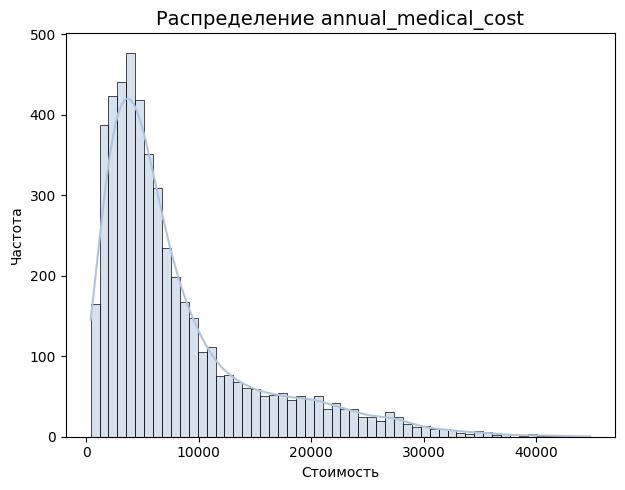

In [18]:
# посмотрим распределение целевой переменной
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='annual_medical_cost', kde=True, color='lightsteelblue', edgecolor='black')
plt.title("Распределение annual_medical_cost", fontsize=14)
plt.xlabel("Стоимость")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

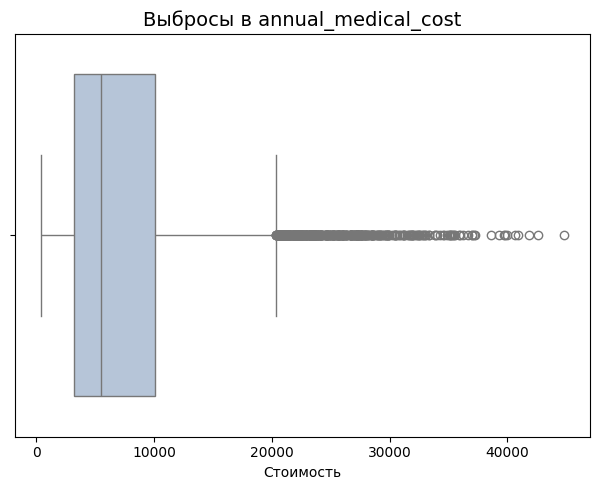

In [19]:
# визуализируем выбросы
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
sns.boxplot(x=df['annual_medical_cost'], color='lightsteelblue')
plt.title("Выбросы в annual_medical_cost", fontsize=14)
plt.xlabel("Стоимость")

plt.tight_layout()
plt.show()

- Мы видим явный "длинный хвост" вправо - большинство людей имеют относительно низкие медицинские расходы.
- Есть небольшое количество записей с очень высокими расходами (25,000-45,000), что говорит о наличии выбросов.
- Распределение далеко от нормального что важно для выбора модели.

In [20]:
df['annual_medical_cost'].skew()

np.float64(1.679655900430324)

Такое значение (≈ 1.68) подтверждает визуальную оценку: распределение имеет умеренную правостороннюю асимметрию.

interval columns not set, guessing: ['age', 'bmi', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'insurance_coverage_pct', 'previous_year_cost', 'annual_medical_cost']


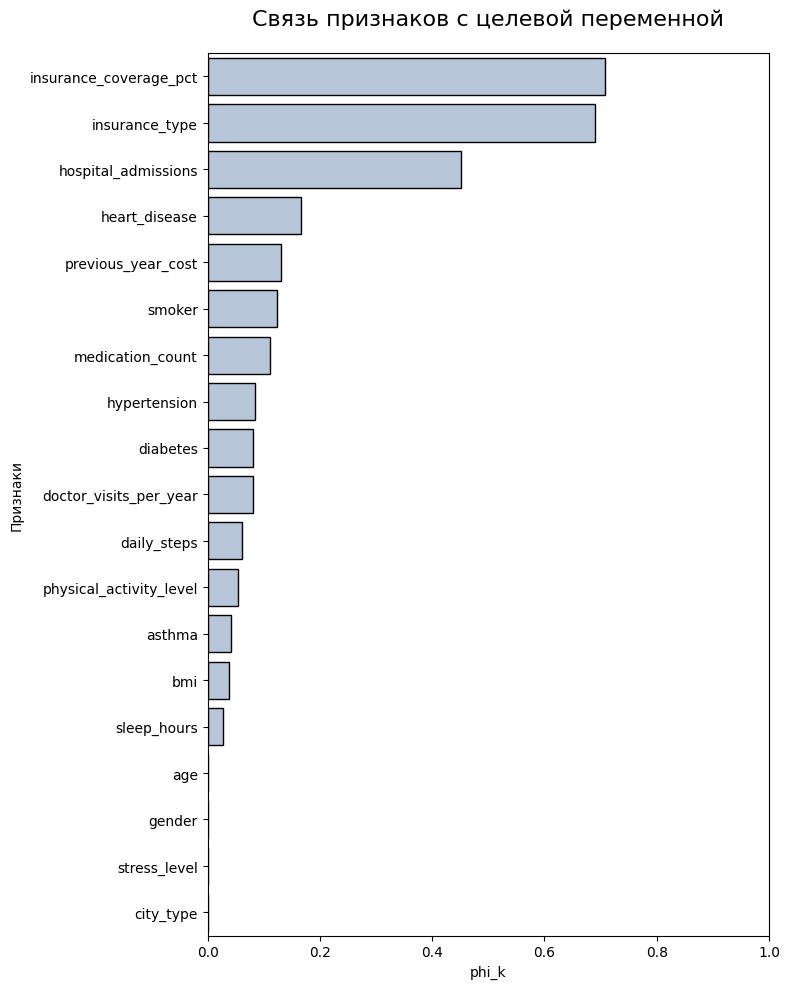

In [21]:
# рассмотрим отдельно связь признаков с целевой переменной
phik_matrix = df.phik_matrix()
target_corr = phik_matrix['annual_medical_cost'].sort_values(ascending=False)

target_corr = target_corr.drop(labels='annual_medical_cost')

plt.figure(figsize=(8, 10))
sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    orient='h',
    color='lightsteelblue', 
    edgecolor='black'
)

plt.title("Связь признаков с целевой переменной", fontsize=16, pad=20)
plt.xlabel("phi_k")
plt.ylabel("Признаки")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

- Наиболее информативные признаки: insurance_coverage_pct, insurance_type, hospital_admissions - они показывают самую высокую связь с целевой переменной.

- Умеренная зависимость: heart_disease, previous_year_cost, smoker, medication_count.

- Остальные признаки имеют слабую зависимость, а age, gender, stress_level и city_type не обнаруживают никакой связи.

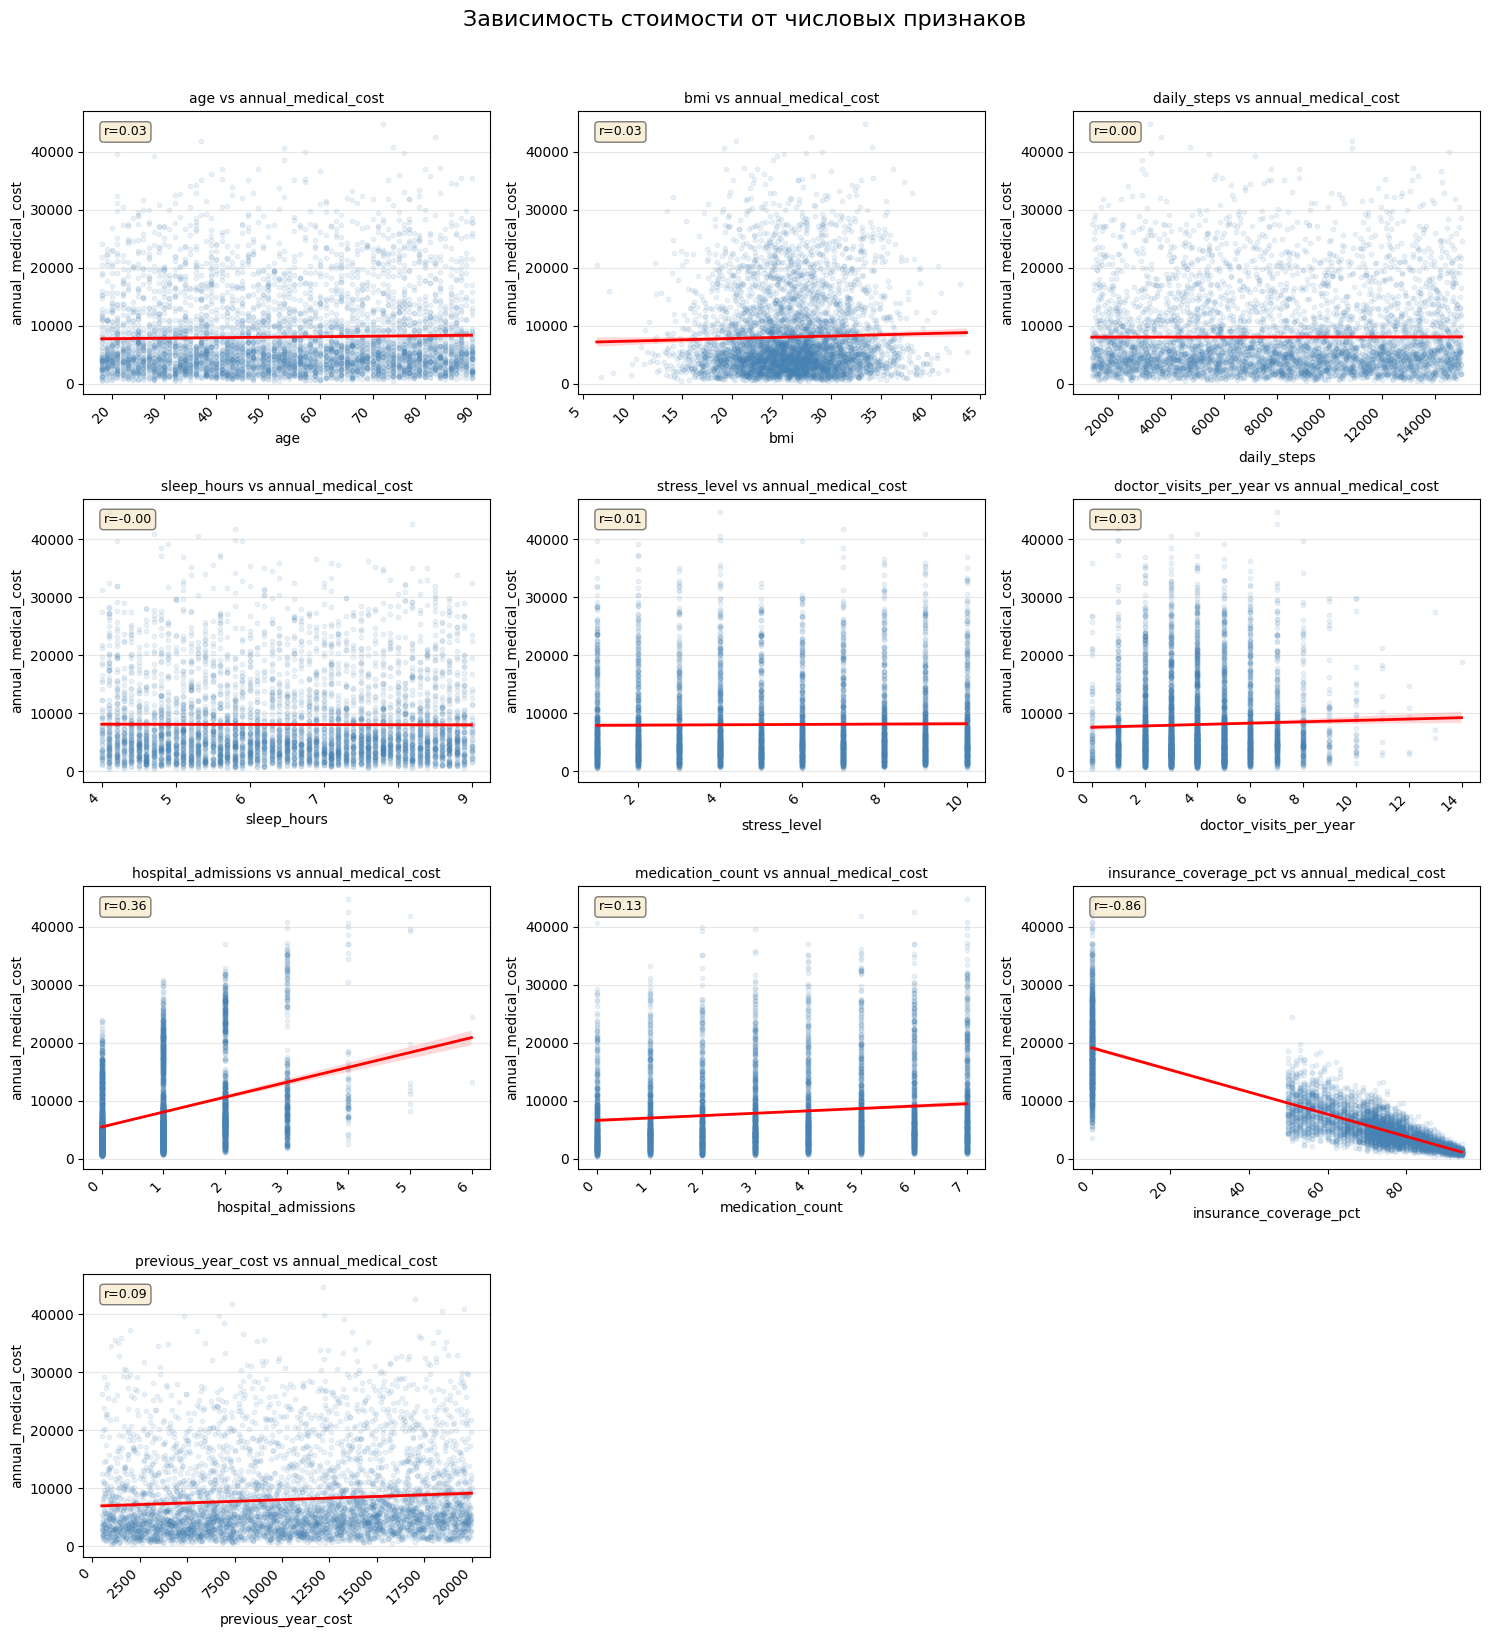

In [22]:
# связь между числовыми признаками и целевой переменной
target_col = "annual_medical_cost" 

n_cols = 3
n_rows = -(-len(numeric) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(numeric):
    ax = axes[i]
    
    sns.regplot(
        data=df,
        x=feature,
        y=target_col,
        scatter_kws={'alpha': 0.1, 's': 10, 'color': 'steelblue'},  # было 0.3
        line_kws={'color': 'red', 'linewidth': 2},
        ax=ax
    )
    
    corr = df[[feature, target_col]].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'r={corr:.2f}', transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_title(f"{feature} vs {target_col}", fontsize=10)
    ax.set_xlabel(feature)
    ax.set_ylabel(target_col)
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

for j in range(len(numeric), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Зависимость стоимости от числовых признаков", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

- Сильная отрицательная корреляция с признаком insurance_coverage_pct (r=-0.86) - чем выше процент покрытия страховки, тем ниже ежегодные расходы (люди с хорошей страховкой платят меньше из "своего кармана").
- Умеренная положительная корреляция с признаком hospital_admissions (r=0.36) - чем больше госпитализаций, тем выше расходы.
- Видна слабая связь с признаками medication_count (r=0.13) и previous_year_cost (r=0.09).
- Практически нет линейной связи с остальными признаками (r < 0.05): age, bmi, daily_steps, sleep_hours, stress_level, doctor_visits_per_year. Это может означать, что признаки действительно не влияют на стоимость или связь нелинейная (например, U-образная для ИМТ или возраста).

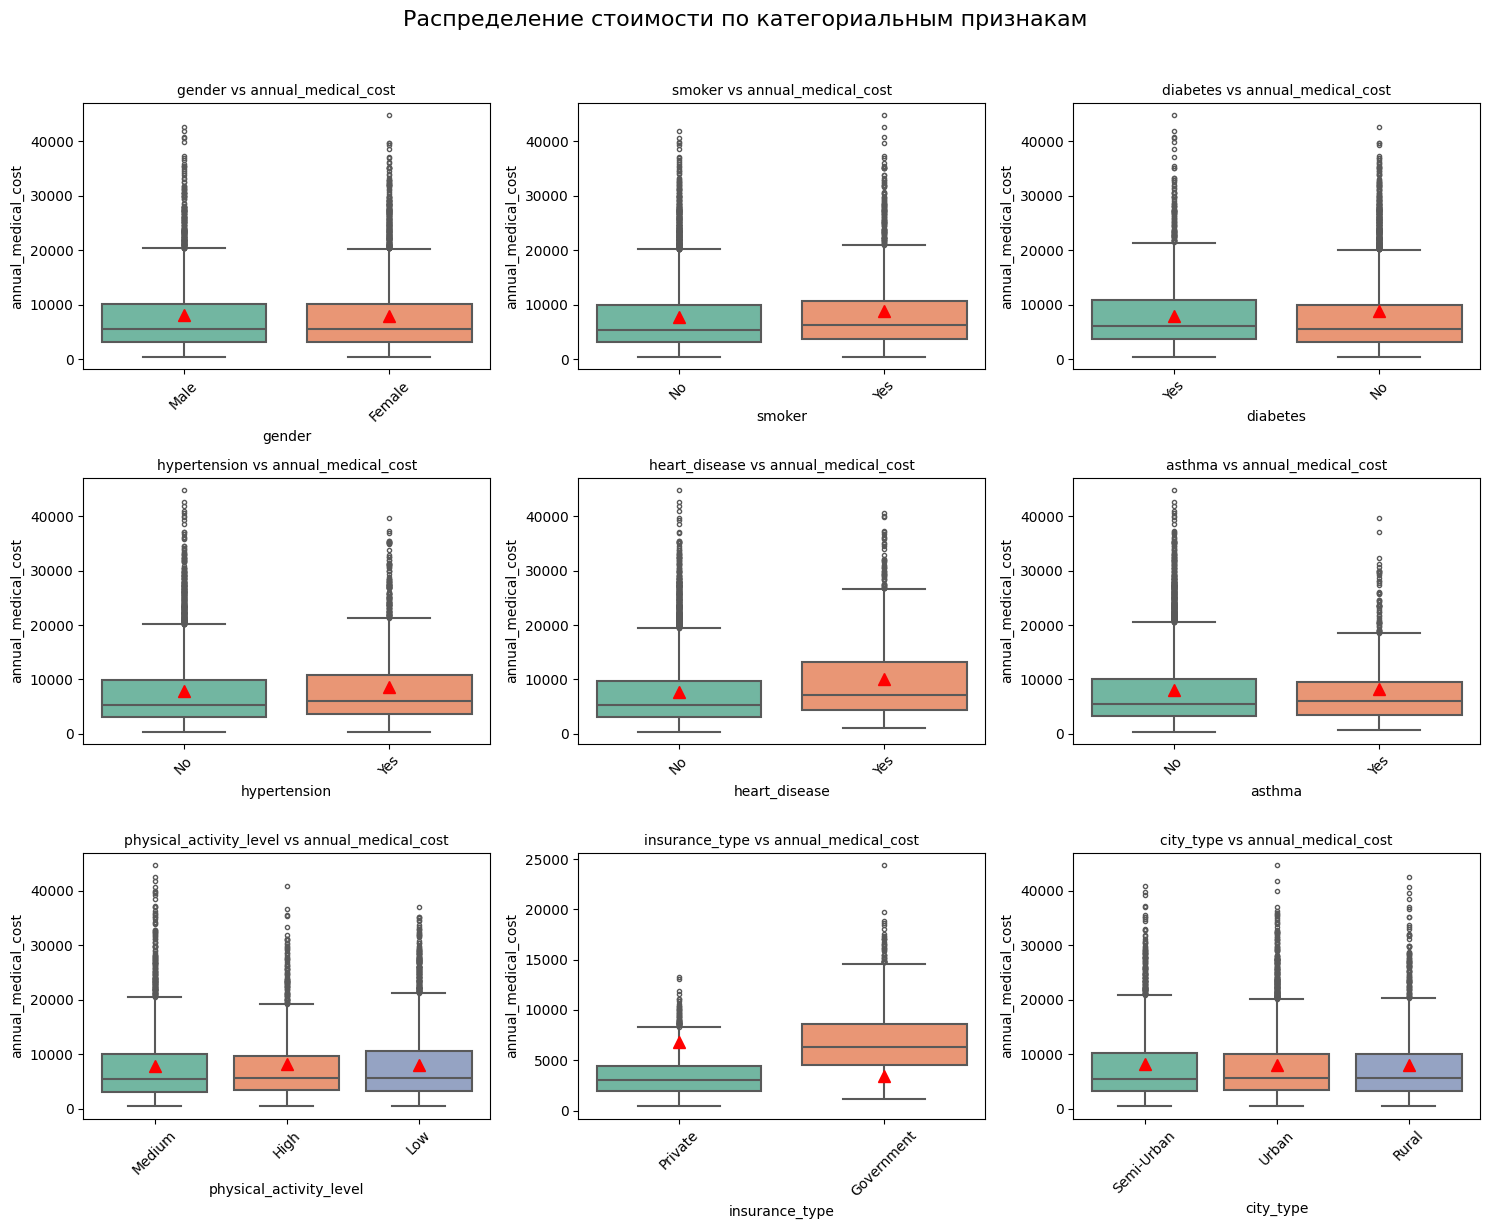

In [23]:
# зависимость категориальных признаков и числовой целевой переменной
target_col = "annual_medical_cost"

n_cols = 3
n_rows = -(-len(categorical) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical):
    
    sns.boxplot(
        data=df,
        x=col,
        y=target_col,
        ax=axes[i],
        hue=col,          
        palette="Set2",     
        legend=False,       
        fliersize=3,
        linewidth=1.5
    )
    
    means = df.groupby(col)[target_col].mean()
    for j, category in enumerate(means.index):
        axes[i].plot(
            j,
            means[category],
            'r^',
            markersize=8,
            label='Среднее' if j == 0 else ""
        )
    
    axes[i].set_title(f"{col} vs {target_col}", fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(categorical), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Распределение стоимости по категориальным признакам", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

- Самые значимые категориальные признаки судя по графикам - insurance_type и heart_disease.
- Медицинские диагнозы (diabetes, hypertension, heart_disease, asthma) не влияют на расходы. Скорее всего, это связано с тем, что данные сгенерированы синтетически.

Выводы по результатам EDA:

1. **Аномалия в данных:** У признака BMI найден экстремально низкий минимум (6.4) — скорее всего, ошибка ввода. Возможно имеет смысл обрезать выброс в этом признаке снизу.

2. **Выбросы по целевой переменной:** Есть небольшая группа людей с аномально высокими расходами на медицину (в 5–8 раз выше средних).

3. **Дисбаланс классов:** Почти все медицинские диагнозы и курение сильно несбалансированы — здоровых людей значительно больше.

4. **Самые важные признаки для предсказания расходов:** процент покрытия страховки (insurance_coverage_pct), тип страховки (insurance_type) и количество госпитализаций (hospital_admissions).

5. **Слабые или нулевые связи:** Возраст, пол, уровень стресса и тип города никак не влияют на расходы (по данным корреляции).

6. **Медицинские диагнозы не влияют** на расходы (диабет, гипертония, астма, болезни сердца).

7. **Распределение расходов — ненормальное:** большинство тратят мало, есть длинный «хвост» из тех, кто тратит очень много.

8. **Для многих моделей нужна нормализация** данных, так как признаки имеют разный масштаб (возраст от 18 до 89, расходы до 45 000).